# S&P500 project by Somov Ivan, Charyshnikov Bogdan, Andrey Sokolov

## Step 0. Project setup and data preparation

Before starting **Step 1 (Joins)**, I prepared the working environment in both **Python/pandas** and **PostgreSQL**, so that the project could be completed into two parts: `steps 1, 2, 5 - via SQL, steps 3 and 4 via pandas`

First, I imported the main libraries used throughout the notebook: `pandas`, `numpy`, `matplotlib`, and `psycopg2`. Then I configured the PostgreSQL connection and created helper functions for:
- connecting to the server,
- creating a new database,
- sending SQL queries and returning results as pandas DataFrames.

As a result of this stage, the project got a dedicated database: **`sp500_project`**.

Next, I prepared the three raw datasets that are required by the project task:
- stock daily prices,
- company metadata with sector information,
- S&P 500 index time series.

At the pandas stage, the raw DataFrames were standardized into:
- `stocks_clean`
- `companies_clean`
- `index_clean`

The main preparation steps were:
- renaming columns to a consistent snake_case format,
- converting date columns to proper datetime/date format,
- sorting observations in the order required for future time-series operations,
- removing problematic rows before loading to SQL.

**Main difficulty at this stage**

One of the first practical issues was that the stock prices dataset contained missing values in `stocks dataframe`. Since incomplete observations could later break return calculations and rolling metrics, I removed rows with null `adj_close` before loading the data into SQL. This made the stock table cleaner and safer for later computations.

**Loading cleaned data into SQL**

After cleaning the data in pandas, I created three SQL tables:
- `stocks`
- `companies`
- `market_index`

Then I inserted the cleaned data into PostgreSQL. For large tables, `batch loading` was used to make the process more efficient. After insertion, I checked that the tables were created successfully and verified row counts.

So, by the end of the setup stage, I had:

- a working PostgreSQL database: `sp500_project`,
- cleaned pandas DataFrames: `stocks_clean`, `companies_clean`, `index_clean`,
- SQL tables ready for analysis: `stocks`, `companies`, `market_index`.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import psycopg2
from psycopg2.extensions import ISOLATION_LEVEL_AUTOCOMMIT
from psycopg2.extras import execute_batch
import seaborn as sns

In [3]:
DB_NAME = "sp500_project"
USER = "postgres"
HOST = "localhost"
PORT = "5432"
PWD_FILE = "pwd.txt"

with open(PWD_FILE, "r") as f:
    PWD = f.read().strip()

In [4]:
def connect(db_nm: str = 'postgres',
            pwd: str = PWD,
            usr_nm: str = USER, 
            host: str = HOST,
            port: str = PORT,
           ) -> psycopg2.extensions.connection | None:
    conn = None
    
    try:
            conn = psycopg2.connect(
            dbname=db_nm,
            user=usr_nm,
            password=pwd,
            host=host,
            port=port
            )
    except Exception as e:
        print(f'Failed to connect to database. Error: {str(e)}')
    else:
        print(f'Connected to database {db_nm}')
    finally:
        return conn

def create_database(db_name: str,
                    usr_nm: str = USER,
                    pwd: str = PWD,
                    host: str = HOST,
                    port: str = PORT) -> None:
    conn = psycopg2.connect(
        dbname='postgres',
        user=usr_nm,
        password=pwd,
        host=host,
        port=port
    )
    conn.set_isolation_level(ISOLATION_LEVEL_AUTOCOMMIT)
    cur = conn.cursor()

    try:
        cur.execute(f"CREATE DATABASE {db_name};")
    except Exception as e:
        print(f"Failed to create database '{db_name}'. Error: {str(e)}")
    else:
        print(f"Database '{db_name}' created.")
    finally:
        cur.close()
        conn.close()

def show_res_of_query(qr: str, cr: psycopg2.extensions.cursor) -> pd.DataFrame:
    cr.execute(qr)
    rows = cr.fetchall()
    cols = [desc[0] for desc in cr.description]
    return pd.DataFrame(rows, columns=cols)

In [12]:
create_database(DB_NAME)

conn = connect(DB_NAME)
cur = conn.cursor()

cur.execute("""
DROP VIEW IF EXISTS step5_ans;
DROP VIEW IF EXISTS step5_market;
DROP VIEW IF EXISTS step5_sector;
DROP VIEW IF EXISTS step4_ans;
DROP VIEW IF EXISTS step3_ans;
DROP VIEW IF EXISTS step1_joined;
DROP VIEW IF EXISTS step1_ans;

DROP TABLE IF EXISTS step5_ans;
DROP TABLE IF EXISTS step5_market;
DROP TABLE IF EXISTS step5_sector;
DROP TABLE IF EXISTS step4_ans;
DROP TABLE IF EXISTS step3_ans;
DROP TABLE IF EXISTS step2_ans;
DROP TABLE IF EXISTS step2_returns;
DROP TABLE IF EXISTS step2_start;
DROP TABLE IF EXISTS stocks;
DROP TABLE IF EXISTS companies;
DROP TABLE IF EXISTS market_index;
""")
conn.commit()

cur.close()
conn.close()

Failed to create database 'sp500_project'. Error: database "sp500_project" already exists

Connected to database sp500_project


In [13]:
stocks = pd.read_csv('sp500_stocks.csv')
companies = pd.read_csv('sp500_companies.csv')
index = pd.read_csv('sp500_index.csv')

stocks_clean = stocks.copy()
companies_clean = companies.copy()
index_clean = index.copy()

stocks_clean = stocks_clean.rename(columns={
    'Date': 'date',
    'Symbol': 'symbol',
    'Adj Close': 'adj_close',
    'Close': 'close',
    'High': 'high',
    'Low': 'low',
    'Open': 'open',
    'Volume': 'volume'
})

companies_clean = companies_clean.rename(columns={
    'Exchange': 'exchange',
    'Symbol': 'symbol',
    'Shortname': 'shortname',
    'Longname': 'longname',
    'Sector': 'sector',
    'Industry': 'industry',
    'Currentprice': 'current_price',
    'Marketcap': 'market_cap',
    'Ebitda': 'ebitda',
    'Revenuegrowth': 'revenue_growth',
    'City': 'city',
    'State': 'state',
    'Country': 'country',
    'Fulltimeemployees': 'fulltime_employees',
    'Longbusinesssummary': 'long_business_summary',
    'Weight': 'weight'
})

index_clean = index_clean.rename(columns={
    'Date': 'date',
    'S&P500': 'sp500'
})

stocks_clean['date'] = pd.to_datetime(stocks_clean['date'])
index_clean['date'] = pd.to_datetime(index_clean['date'])

stocks_clean = stocks_clean.dropna(subset=['adj_close']).copy()

stocks_clean = stocks_clean.sort_values(['symbol', 'date']).reset_index(drop=True)
companies_clean = companies_clean.sort_values('symbol').reset_index(drop=True)
index_clean = index_clean.sort_values('date').reset_index(drop=True)

stocks_clean['date'] = stocks_clean['date'].dt.date
index_clean['date'] = index_clean['date'].dt.date

In [14]:
conn = connect(DB_NAME)
cur = conn.cursor()

cur.execute("""
DROP TABLE IF EXISTS stocks;
DROP TABLE IF EXISTS companies;
DROP TABLE IF EXISTS market_index;
""")

cur.execute("""
CREATE TABLE companies (
    exchange TEXT,
    symbol TEXT PRIMARY KEY,
    shortname TEXT,
    longname TEXT,
    sector TEXT,
    industry TEXT,
    current_price DOUBLE PRECISION,
    market_cap BIGINT,
    ebitda DOUBLE PRECISION,
    revenue_growth DOUBLE PRECISION,
    city TEXT,
    state TEXT,
    country TEXT,
    fulltime_employees DOUBLE PRECISION,
    long_business_summary TEXT,
    weight DOUBLE PRECISION
);
""")

cur.execute("""
CREATE TABLE market_index (
    date DATE PRIMARY KEY,
    sp500 DOUBLE PRECISION
);
""")

cur.execute("""
CREATE TABLE stocks (
    date DATE,
    symbol TEXT,
    adj_close DOUBLE PRECISION,
    close DOUBLE PRECISION,
    high DOUBLE PRECISION,
    low DOUBLE PRECISION,
    open DOUBLE PRECISION,
    volume DOUBLE PRECISION,
    PRIMARY KEY (symbol, date)
);
""")

print("Tables created.")


# Inserting values into tables
companies_rows = list(companies_clean.itertuples(index=False, name=None))

insert_companies = """
INSERT INTO companies (
    exchange, symbol, shortname, longname, sector, industry,
    current_price, market_cap, ebitda, revenue_growth,
    city, state, country, fulltime_employees,
    long_business_summary, weight
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
"""

execute_batch(cur, insert_companies, companies_rows, page_size=1000)
print("companies loaded.")


index_rows = list(index_clean.itertuples(index=False, name=None))

insert_index = """
INSERT INTO market_index (date, sp500)
VALUES (%s, %s);
"""

execute_batch(cur, insert_index, index_rows, page_size=1000)
conn.commit()
cur.close()
conn.close()

print("market_index loaded.")

def load_stocks_in_chunks(df, chunk_size=50000):
    conn = connect(DB_NAME)
    cur = conn.cursor()

    insert_stocks = """
    INSERT INTO stocks (
        date, symbol, adj_close, close, high, low, open, volume
    )
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s);
    """

    total_rows = len(df)

    for start in range(0, total_rows, chunk_size):
        end = min(start + chunk_size, total_rows)
        chunk = df.iloc[start:end]

        rows = list(chunk.itertuples(index=False, name=None))
        execute_batch(cur, insert_stocks, rows, page_size=5000)
        conn.commit()

        print(f"Loaded rows {start} to {end} out of {total_rows}")

    cur.close()
    conn.close()
    print("stocks loaded.")

load_stocks_in_chunks(stocks_clean)

Connected to database sp500_project
Tables created.
companies loaded.
market_index loaded.
Connected to database sp500_project
Loaded rows 0 to 50000 out of 617831
Loaded rows 50000 to 100000 out of 617831
Loaded rows 100000 to 150000 out of 617831
Loaded rows 150000 to 200000 out of 617831
Loaded rows 200000 to 250000 out of 617831
Loaded rows 250000 to 300000 out of 617831
Loaded rows 300000 to 350000 out of 617831
Loaded rows 350000 to 400000 out of 617831
Loaded rows 400000 to 450000 out of 617831
Loaded rows 450000 to 500000 out of 617831
Loaded rows 500000 to 550000 out of 617831
Loaded rows 550000 to 600000 out of 617831
Loaded rows 600000 to 617831 out of 617831
stocks loaded.


In [15]:
conn = connect(DB_NAME)
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM stocks;")
print("stocks rows:", cur.fetchone()[0])

cur.execute("SELECT COUNT(*) FROM companies;")
print("companies rows:", cur.fetchone()[0])

cur.execute("SELECT COUNT(*) FROM market_index;")
print("market_index rows:", cur.fetchone()[0])

cur.close()
conn.close()

Connected to database sp500_project
stocks rows: 617831
companies rows: 502
market_index rows: 2517


## Step 1. Joins (SQL)

SQL joins were used to combine the three sources into one table:

1. **Stock prices** were taken as the base table.
2. **Company metadata** was joined by `symbol`.
3. **Market index values** were joined by `date`.

As a result, each row of the final joined table corresponds to **one stock on one date**, enriched with:
- stock price information,
- company sector,
- S&P 500 market index information for the same date.

The output of this step was stored in an SQL view as:

- `step1_ans`

**Difficulty:**
Dates for companies and index did not match fully, so as a final preparation for step 2 null values were dropped

This completed the data integration stage and prepared the project for **Step 2**

In [16]:
conn = connect(DB_NAME)
cur = conn.cursor()

query = """
DROP VIEW IF EXISTS step1_ans;

CREATE VIEW step1_ans AS
SELECT
    s.*,
    c.sector,
    c.industry,
    c.weight,
    m.sp500
FROM stocks s
LEFT JOIN companies c
    ON s.symbol = c.symbol
LEFT JOIN market_index m
    ON s.date = m.date;
"""
cur.execute(query)
conn.commit()

query = '''
SELECT * FROM step1_ans LIMIT 5
'''
print(show_res_of_query(query, cur))

cur.close()
conn.close()

print("View step1_ans was created. \n It is the result of step1 of the project")

Connected to database sp500_project
         date symbol  adj_close      close       high        low       open  \
0  2013-01-02   ABBV  21.629181  35.119999  35.400002  34.099998  34.919998   
1  2013-01-03   ABBV  21.450581  34.830002  35.000000  34.160000  35.000000   
2  2013-01-04   ABBV  21.179594  34.389999  34.889999  34.250000  34.619999   
3  2013-01-07   ABBV  21.222700  34.459999  35.450001  34.150002  34.150002   
4  2013-01-08   ABBV  20.760809  33.709999  34.639999  33.360001  34.290001   

       volume      sector                      industry    weight sp500  
0  13767900.0  Healthcare  Drug Manufacturers - General  0.005582  None  
1  16739300.0  Healthcare  Drug Manufacturers - General  0.005582  None  
2  21372100.0  Healthcare  Drug Manufacturers - General  0.005582  None  
3  17897100.0  Healthcare  Drug Manufacturers - General  0.005582  None  
4  17863300.0  Healthcare  Drug Manufacturers - General  0.005582  None  
View step1_ans was created. 
 It is the resul

In [17]:
conn = connect(DB_NAME)
cur = conn.cursor()

query = '''
DROP TABLE IF EXISTS step2_start;
    
CREATE TABLE step2_start AS
SELECT * FROM step1_ans
WHERE sp500 IS NOT NULL;
'''
cur.execute(query)
conn.commit()

query = '''
SELECT * FROM step2_start LIMIT 5
'''
print(show_res_of_query(query, cur))

cur.close()
conn.close()

Connected to database sp500_project
         date symbol  adj_close      close       high        low       open  \
0  2014-12-22   ABBV  44.277233  66.970001  68.250000  66.830002  68.040001   
1  2014-12-23   ABBV  42.545006  64.349998  67.320000  64.019997  67.230003   
2  2014-12-24   ABBV  43.774754  66.209999  66.949997  64.750000  64.750000   
3  2014-12-26   ABBV  44.283840  66.980003  67.239998  66.510002  66.510002   
4  2014-12-29   ABBV  44.389626  67.139999  67.370003  66.419998  66.580002   

       volume      sector                      industry    weight    sp500  
0  12876600.0  Healthcare  Drug Manufacturers - General  0.005582  2078.54  
1  12123000.0  Healthcare  Drug Manufacturers - General  0.005582  2082.17  
2   4705500.0  Healthcare  Drug Manufacturers - General  0.005582  2081.88  
3   4158200.0  Healthcare  Drug Manufacturers - General  0.005582  2088.77  
4   3872800.0  Healthcare  Drug Manufacturers - General  0.005582  2090.57  


## Step 2. Returns and beta calculations (SQL)

Using the joined SQL table `step2_start` from previous step, were calculated:

- `stock_return` — daily return for each stock based on adjusted close prices,
- `market_return` — daily return of the S&P 500 index,
- `market_adj_return` — stock return net of market return,
- `beta_60` — rolling approximation of stock beta using a 60-day window, 

The output of this step was stored in:

- SQL table: `step2_ans`

**Main difficulty**

The key issue is that returns cannot be calculated from a single row alone — each observation depends on the previous date for the same stock or for the market index. This required careful use of `ordering and partitioning logic in SQL window functions.`

Another issue was that rolling metrics naturally produce `missing values` at the beginning of each series because a full historical window is not yet available. Those values were dropped.

**Functions used:** CORR, STDDEV_SAMP, LAG, 60-day rolling window (ROWS BETWEEN 59 PRECEEDING AND CURRENT ROW)

In [18]:
# Returns calculation
conn = connect(DB_NAME)
cur = conn.cursor()

query = '''
DROP TABLE IF EXISTS step2_returns;

CREATE TABLE step2_returns AS
SELECT 
    final.*,
    stock_return - market_return AS market_adj_return
FROM (
    SELECT 
        s.date,
        symbol,
        adj_close,
        adj_close / LAG(adj_close) OVER (PARTITION BY symbol ORDER BY s.date ASC) - 1 AS stock_return,
        market_return,
        s.sector,
        s.industry,
        s.weight
    FROM step2_start s
    LEFT JOIN (
        SELECT m.date, m.sp500,
        sp500 / LAG(sp500) OVER () - 1 AS market_return
        FROM market_index m
    ) m ON s.date = m.date
    ORDER BY symbol, s.date
) AS final
WHERE stock_return IS NOT NULL AND market_return IS NOT NULL;
'''
cur.execute(query)
conn.commit()

query = '''
SELECT * FROM step2_returns LIMIT 5
'''
print(show_res_of_query(query, cur))

cur.close()
conn.close()

Connected to database sp500_project
         date symbol  adj_close  stock_return  market_return      sector  \
0  2014-12-23   ABBV  42.545006     -0.039122       0.001746  Healthcare   
1  2014-12-24   ABBV  43.774754      0.028905      -0.000139  Healthcare   
2  2014-12-26   ABBV  44.283840      0.011630       0.003310  Healthcare   
3  2014-12-29   ABBV  44.389626      0.002389       0.000862  Healthcare   
4  2014-12-30   ABBV  43.834248     -0.012511      -0.004889  Healthcare   

                       industry    weight  market_adj_return  
0  Drug Manufacturers - General  0.005582          -0.040869  
1  Drug Manufacturers - General  0.005582           0.029044  
2  Drug Manufacturers - General  0.005582           0.008320  
3  Drug Manufacturers - General  0.005582           0.001527  
4  Drug Manufacturers - General  0.005582          -0.007623  


In [19]:
# Beta calculation. Beta = correlation(stock, market) * std(stock) / std(market) over 60-day window
conn = connect(DB_NAME)
cur = conn.cursor()

query = '''
DROP TABLE IF EXISTS step2_ans;

CREATE TABLE step2_ans AS
SELECT 
    final.date,
    final.symbol,
    final.adj_close,
    final.sector,
    final.industry,
    final.weight,
    final.stock_return,
    final.market_return,
    final.market_adj_return,
    corr_60 * std_stock_60 / std_market_60 AS beta_60
FROM(
    SELECT 
        s_ret.*,
        CORR(stock_return, market_return) OVER (
            PARTITION BY symbol ORDER BY date ASC
            ROWS BETWEEN 59 PRECEDING AND CURRENT ROW
                                                ) AS corr_60,
        STDDEV_SAMP(stock_return) OVER (
            PARTITION BY symbol ORDER BY date ASC
            ROWS BETWEEN 59 PRECEDING AND CURRENT ROW
                                                ) AS std_stock_60,
        STDDEV_SAMP(market_return) OVER (
            PARTITION BY symbol ORDER BY date ASC
            ROWS BETWEEN 59 PRECEDING AND CURRENT ROW
                                                ) AS std_market_60,
        COUNT(*) OVER (
            PARTITION BY symbol ORDER BY date
            ROWS BETWEEN 59 PRECEDING AND CURRENT ROW
                                                ) AS n_obs_60
    FROM step2_returns s_ret
    ) final
WHERE corr_60 IS NOT NULL AND std_stock_60 IS NOT NULL AND std_market_60 IS NOT NULL AND n_obs_60 = 60
;
'''
cur.execute(query)
conn.commit()

query = '''
SELECT * FROM step2_ans LIMIT 5
'''
print(show_res_of_query(query, cur))

cur.close()
conn.close()

print('\n Table step2_ans was created. It is the result of step2 of the project')

Connected to database sp500_project
         date symbol  adj_close      sector                      industry  \
0  2015-03-20   ABBV  40.233265  Healthcare  Drug Manufacturers - General   
1  2015-03-23   ABBV  40.286549  Healthcare  Drug Manufacturers - General   
2  2015-03-24   ABBV  39.720348  Healthcare  Drug Manufacturers - General   
3  2015-03-25   ABBV  38.781143  Healthcare  Drug Manufacturers - General   
4  2015-03-26   ABBV  38.148315  Healthcare  Drug Manufacturers - General   

     weight  stock_return  market_return  market_adj_return   beta_60  
0  0.005582     -0.012911       0.009013          -0.021923  1.166020  
1  0.005582      0.001324      -0.001746           0.003070  1.177493  
2  0.005582     -0.014054      -0.006139          -0.007915  1.187462  
3  0.005582     -0.023645      -0.014559          -0.009087  1.195398  
4  0.005582     -0.016318      -0.002377          -0.013940  1.200035  

 Table step2_ans was created. It is the result of step2 of the proje

## Step 3. Ranking and z-scores, leaders and laggards (PANDAS)

Using the analytical dataset from previous step, the following cross-sectional metrics were computed **within each (`sector`, `date`) group**:

- `rank_return` — rank of each stock by daily `stock_return`,
- `rank_market_adj` — rank by `market_adj_return`,
- `rank_beta` — rank by `beta_60`,
- `rank_volatility` — rank by `volatility_20`,
- `z_return` — sector-day z-score of `stock_return`,
- `z_market_adj` — sector-day z-score of `market_adj_return`,
- `z_beta` — sector-day z-score of `beta_60`,
- `z_volatility` — sector-day z-score of `volatility_20`.

Then, based on these ranks, boolean indicators were created to identify **leaders** and **laggards** for each metric:

- `leader_return`, `laggard_return`
- `leader_market_adj`, `laggard_market_adj`
- `leader_beta`, `laggard_beta`
- `leader_volatility`, `laggard_volatility`

The idea of this step was to move from raw return/risk variables to **relative sector-level positioning**: not just how a stock performed in absolute terms, but how it performed **relative to other stocks in the same sector on the same date**.

The output of this step was stored in:

- pandas DataFrame: `df3_ranking`

**Main difficulty**

The key issue is that Step 3 is **cross-sectional**, not purely time-series based.  
Each metric had to be evaluated **inside sector-day groups**, so the logic depended on correct use of:

- `groupby(['sector', 'date'])`
- `rank(...)`
- `transform('mean')`
- `transform('std')`

Another difficulty was handling interpretation of ranks for different metrics. For example:

- for `return` and `market_adj_return`, higher values naturally correspond to stronger performers,
- for `volatility` and `beta`, there is no clear interpretation higher or lower values are better.

`Volatility_20` as a rolling metric produced none values that were dropped.

**Functions used:** `groupby`, `rank`, `transform`, boolean conditions, within-group z-score calculation

In [21]:
# Storing dataframe to work with
conn = connect(DB_NAME)
cur = conn.cursor()

query = '''
SELECT * FROM step2_ans;'''

df3 = show_res_of_query(query, cur)

cur.close()
conn.close()

print(df3.head(2))
print('\n')
print(df3.shape)

Connected to database sp500_project
         date symbol  adj_close      sector                      industry  \
0  2015-03-20   ABBV  40.233265  Healthcare  Drug Manufacturers - General   
1  2015-03-23   ABBV  40.286549  Healthcare  Drug Manufacturers - General   

     weight  stock_return  market_return  market_adj_return   beta_60  
0  0.005582     -0.012911       0.009013          -0.021923  1.166020  
1  0.005582      0.001324      -0.001746           0.003070  1.177493  


(413017, 10)


In [22]:
# Volatility calculation
df3['date'] = pd.to_datetime(df3['date'])
df3 = df3.sort_values(by=['symbol', 'date'])
df3['volatility_20'] = (
    df3.groupby('symbol')['stock_return']
       .rolling(window=20, min_periods=20)
       .std()
       .reset_index(drop=True)
)

In [23]:
df3_ranking = df3.dropna(subset=['volatility_20']).copy()

# ranking for (sector, date) by return, adjusted return, beta, volatility (20 day)

df3_ranking['rank_return'] = (
    df3_ranking.groupby(['sector', 'date'])['stock_return']
             .rank(method='dense', ascending=False)
)

df3_ranking['rank_market_adj'] = (
    df3_ranking.groupby(['sector', 'date'])['market_adj_return']
             .rank(method='dense', ascending=False)
)

df3_ranking['rank_beta'] = (
    df3_ranking.groupby(['sector', 'date'])['beta_60']
             .rank(method='dense', ascending=False)
)

df3_ranking['rank_volatility'] = (
    df3_ranking.groupby(['sector', 'date'])['volatility_20']
             .rank(method='dense', ascending=True)
)

In [24]:
# Sector avg and std for each of four metrics

df3_ranking['sector_avg_return'] = (
    df3_ranking.groupby(['sector', 'date'])['stock_return']
             .transform('mean')
)

df3_ranking['sector_std_return'] = (
    df3_ranking.groupby(['sector', 'date'])['stock_return']
             .transform('std')
)

df3_ranking['sector_avg_market_adj'] = (
    df3_ranking.groupby(['sector', 'date'])['market_adj_return']
             .transform('mean')
)

df3_ranking['sector_std_market_adj'] = (
    df3_ranking.groupby(['sector', 'date'])['market_adj_return']
             .transform('std')
)

df3_ranking['sector_avg_beta'] = (
    df3_ranking.groupby(['sector', 'date'])['beta_60']
             .transform('mean')
)

df3_ranking['sector_std_beta'] = (
    df3_ranking.groupby(['sector', 'date'])['beta_60']
             .transform('std')
)

df3_ranking['sector_avg_volatility'] = (
    df3_ranking.groupby(['sector', 'date'])['volatility_20']
             .transform('mean')
)

df3_ranking['sector_std_volatility'] = (
    df3_ranking.groupby(['sector', 'date'])['volatility_20']
             .transform('std')
)

In [25]:
# z-scores calculation

df3_ranking['z_return'] = (
    (df3_ranking['stock_return'] - df3_ranking['sector_avg_return']) /
    df3_ranking['sector_std_return']
)

df3_ranking['z_market_adj'] = (
    (df3_ranking['market_adj_return'] - df3_ranking['sector_avg_market_adj']) /
    df3_ranking['sector_std_market_adj']
)

df3_ranking['z_beta'] = (
    (df3_ranking['beta_60'] - df3_ranking['sector_avg_beta']) /
    df3_ranking['sector_std_beta']
)

df3_ranking['z_volatility'] = (
    (df3_ranking['volatility_20'] - df3_ranking['sector_avg_volatility']) /
    df3_ranking['sector_std_volatility']
)

In [26]:
# Leaders boolen mask
df3_ranking['leader_return'] = df3_ranking['rank_return'] == 1
df3_ranking['leader_market_adj'] = df3_ranking['rank_market_adj'] == 1
df3_ranking['leader_beta'] = df3_ranking['rank_beta'] == 1
df3_ranking['leader_volatility'] = df3_ranking['rank_volatility'] == 1

# Laggards boolen mask
df3_ranking['laggard_return'] = (
    df3_ranking['rank_return'] ==
    df3_ranking.groupby(['sector', 'date'])['rank_return'].transform('max')
)

df3_ranking['laggard_market_adj'] = (
    df3_ranking['rank_market_adj'] ==
    df3_ranking.groupby(['sector', 'date'])['rank_market_adj'].transform('max')
)

df3_ranking['laggard_beta'] = (
    df3_ranking['rank_beta'] ==
    df3_ranking.groupby(['sector', 'date'])['rank_beta'].transform('max')
)

df3_ranking['laggard_volatility'] = (
    df3_ranking['rank_volatility'] ==
    df3_ranking.groupby(['sector', 'date'])['rank_volatility'].transform('max')
)

In [28]:
# Sample output. Masks are used to print df with leaders and laggards
check = (df3_ranking[df3_ranking['leader_return'] | df3_ranking['leader_market_adj'] |
         df3_ranking['leader_beta'] | df3_ranking['leader_volatility'] | df3_ranking['laggard_return'] |
         df3_ranking['laggard_market_adj'] | df3_ranking['laggard_beta'] | df3_ranking['laggard_volatility']
        ])[[
    'date', 'sector', 'symbol',
    'stock_return', 'rank_return', 'z_return',
    'market_adj_return', 'rank_market_adj', 'z_market_adj',
    'beta_60', 'rank_beta', 'z_beta',
    'volatility_20', 'rank_volatility', 'z_volatility' 
]]
check.head(3)

,date,sector,symbol,stock_return,rank_return,z_return,market_adj_return,rank_market_adj,z_market_adj,beta_60,rank_beta,z_beta,volatility_20,rank_volatility,z_volatility
20,2015-04-20,Healthcare,ABBV,0.020067,4.0,0.677318,0.010832,4.0,0.677318,1.239458,1.0,1.551175,0.014575,13.0,0.029112
21,2015-04-21,Healthcare,ABBV,0.001102,14.0,-0.440737,0.002582,14.0,-0.440737,1.234622,1.0,1.653538,0.014576,13.0,-0.000124
22,2015-04-22,Healthcare,ABBV,0.014306,2.0,1.087153,0.009218,2.0,1.087153,1.243040,1.0,1.795960,0.014200,12.0,-0.073572


## Step 4. Volatility regimes and market state classification (PANDAS)

Using the previously calculated `volatility_20`, a market-wide volatility proxy was constructed:

- `VIX_proxy` — average `volatility_20` across all stocks on each date, annualized and multiplied by 100.

Then, following the project specification, each trading day was classified into one of four volatility regimes:

- `low` — `VIX_proxy < 15`
- `normal` — `15 <= VIX_proxy < 25`
- `high` — `25 <= VIX_proxy <= 40`
- `extreme` — `VIX_proxy > 40`

After regime classification, transition and duration logic was added:

- `transition` — indicates whether the regime changed relative to the previous day,
- `regime_group` — identifies continuous blocks of the same regime,
- `duration_days` — number of consecutive trading days in each regime episode,
- `total_duration` — total number of trading days spent in each regime over the full sample.

The idea of this step was to move from stock-level volatility to a **market-level regime view** and describe how market conditions evolved over time.

The main outputs of this step were stored in:

- pandas DataFrame: `df4_VIX` (VIX approximation)
- pandas DataFrame: `df4_durations_fully` (duration and start-end dates of each VIX regime)
- pandas DataFrame: `tot_dur` (total duration of each regime)

**Main difficulty**

The key issue is that the project asks for a **proxy for VIX**, not the actual VIX index.  
Since option-implied volatility data were not available, the proxy had to be built from the available stock-level data. The chosen solution was to average cross-stock rolling volatility and annualize it, which makes the scale comparable to standard volatility regime thresholds.

Another difficulty was interpreting **duration** correctly.  
At first, duration could be understood as the total number of days in each regime, but the transition logic in the project specification implies a more detailed meaning: duration of each **continuous regime episode**. This required identifying regime changes first and then grouping consecutive days into separate regime blocks.

**Functions used:** `groupby`, `mean`, `shift`, boolean conditions, `cumsum`, `agg`

In [29]:
df4 = df3_ranking[['date', 'symbol', 'volatility_20']].copy() 
df4.head(3)

,date,symbol,volatility_20
19,2015-04-17,ABBV,0.014413
20,2015-04-20,ABBV,0.014575
21,2015-04-21,ABBV,0.014576


In [1]:
# use previously calculated volatility_20 mean annualized as VIX_proxy
portfolio_returns = df4.groupby('date')['stock_return'].mean()
series_VIX = (
    portfolio_returns
    .rolling(20)
    .std()
    * np.sqrt(252)
    * 100
)

# regimes 
df4_VIX = series_VIX.to_frame().reset_index(drop=False)
df4_VIX = df4_VIX.rename(columns={'volatility_20' : 'VIX_proxy'})
df4_VIX.loc[df4_VIX['VIX_proxy'] < 15, ['regime']] = 'low'  
df4_VIX.loc[(df4_VIX['VIX_proxy'] >= 15) & (df4_VIX['VIX_proxy'] < 25), ['regime']] = 'normal'
df4_VIX.loc[(df4_VIX['VIX_proxy'] >= 25) & (df4_VIX['VIX_proxy'] < 40), ['regime']] = 'high'
df4_VIX.loc[df4_VIX['VIX_proxy'] >= 40, ['regime']] = 'extreme'  
print(df4_VIX.head())
print('\n' + '--'*40 + '\n')

# transitions
df4_VIX['transition'] = False
df4_VIX.loc[df4_VIX['regime'] != df4_VIX['regime'].shift(1), ['transition']] = True
df4_VIX.iloc[0, 3] = False  # set first observation False because no previous observation
df4_transitions = df4_VIX[df4_VIX['transition']]
print(df4_transitions.head())
print('\n' + '--'*40 + '\n')

# duration of each period
df4_dur_prep = df4_VIX.copy()
df4_dur_prep['regime_group'] = df4_dur_prep['transition'].cumsum()
df4_durations_fully = (
    df4_dur_prep.groupby('regime_group')
    .agg(
        regime=('regime', 'first'),
        start_date=('date', 'min'),
        end_date=('date', 'max'),
        duration_days=('date', 'count')
    )
    .reset_index(drop=True)
)
print(df4_durations_fully.head())
print('\n' + '--'*40 + '\n')

# total duration
tot_dur = df4_VIX.groupby('regime').agg(total_duration=('date', 'count')).reset_index(drop=False)[['regime', 'total_duration']]
print(tot_dur)

NameError: name 'df4' is not defined

## Step 5. Market breadth and advance-decline lines (SQL)

Using the stock-level dataset from `step2_ans`, market breadth was measured through the **advance-decline framework**.

For each date and each sector, the following daily counts were calculated:

- `adv_count` — number of stocks with `stock_return > 0`,
- `decl_count` — number of stocks with `stock_return < 0`,
- `total_count` — total number of stocks in the group,
- `net_adv = adv_count - decl_count`.

Based on these values, two cumulative breadth indicators were constructed:

- `cum_line` — cumulative sum of `net_adv` within each sector,
- `cum_line_market` — cumulative sum of `net_adv` for the whole market.

These variables provide the standard advance-decline line required by the project specification.

In addition, normalized breadth measures were also computed for future visualization purposes:

- `net_adv_ratio = 1.0 * (adv_count - decl_count) / total_count`,
- `cum_line_ratio` — cumulative sum of `net_adv_ratio` within each sector,
- `cum_line_ratio_market` — cumulative sum of `net_adv_ratio` for the whole market.

The normalized version was added because raw cumulative breadth is not directly comparable across groups of different sizes: the market always contains many more stocks than an individual sector. Dividing daily net advances by `total_count` makes sector-level and market-level lines more comparable.

The main outputs of this step were stored in:

- pandas DataFrame: `df5_market_sql`
- pandas DataFrame: `df5_sectors_sql`

**Main difficulty**

The main issue in this step was interpretability of the final line.  
A raw advance-decline line is valid as a formal breadth measure, but when sectors are plotted together with the overall market, the market line can dominate mechanically because it is based on a much larger number of stocks. To handle this, the SQL logic was extended with a normalized daily breadth component (`net_adv_ratio`), which preserves the idea of market breadth while making later comparisons more meaningful.

**SQL techniques used:** `COUNT`, `CASE WHEN`, arithmetic expressions, `GROUP BY`, window `SUM() OVER (...)`, `PARTITION BY`

In [32]:
# Advance-decline line for market
conn = connect(DB_NAME)
cur = conn.cursor()

query = '''
SELECT
    date,
    SUM(net_adv) OVER (
        ORDER BY date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cum_line_market,
    ROUND(SUM(net_adv_ratio) OVER (
        ORDER BY date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ), 2) AS cum_line_ratio_market
FROM (
    SELECT
        date,
        adv_count - decl_count AS net_adv,
        1.0 * (adv_count - decl_count) / total_count AS net_adv_ratio
    FROM (
        SELECT
            date,
            COUNT(CASE WHEN stock_return > 0 THEN 1 END) AS adv_count,
            COUNT(CASE WHEN stock_return < 0 THEN 1 END) AS decl_count,
            COUNT(*) AS total_count
        FROM step2_ans
        GROUP BY date
    )
)
;
'''

df5_market_sql = show_res_of_query(query, cur)
print(df5_market_sql.head(3))

cur.close()
conn.close()

Connected to database sp500_project
         date cum_line_market cum_line_ratio_market
0  2015-03-20             104                  0.64
1  2015-03-23              61                  0.38
2  2015-03-24             -12                 -0.07


In [33]:
# Advance-decline line for sectors
conn = connect(DB_NAME)
cur = conn.cursor()

query = '''
SELECT
    date,
    sector,
    SUM(net_adv) OVER (
        PARTITION BY sector
        ORDER BY date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cum_line,
    ROUND(SUM(net_adv_ratio) OVER (
        PARTITION BY sector
        ORDER BY date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ), 2) AS cum_line_ratio
FROM (
    SELECT
        date,
        sector,
        adv_count - decl_count AS net_adv,
        1.0 * (adv_count - decl_count) / total_count AS net_adv_ratio
    FROM (
        SELECT
            date,
            sector,
            COUNT(CASE WHEN stock_return > 0 THEN 1 END) AS adv_count,
            COUNT(CASE WHEN stock_return < 0 THEN 1 END) AS decl_count,
            COUNT(*) AS total_count
        FROM step2_ans
        GROUP BY date, sector
        ORDER BY sector, date
    )
)
;
'''

df5_sectors_sql = show_res_of_query(query, cur)
print(df5_sectors_sql.head(3))

cur.close()
conn.close()

Connected to database sp500_project
         date           sector cum_line cum_line_ratio
0  2015-03-20  Basic Materials        7           1.00
1  2015-03-23  Basic Materials        4           0.57
2  2015-03-24  Basic Materials        1           0.14


### Normalized Advance-Decline Line: Sectors vs Market

This chart shows the cumulative normalized advance-decline line for each sector and for the overall market.

For each day, the number of advancing stocks is compared with the number of declining stocks and then normalized by the size of the group. The cumulative line helps track market breadth over time and makes sector-level trends comparable with the broader market despite differences in the number of stocks.

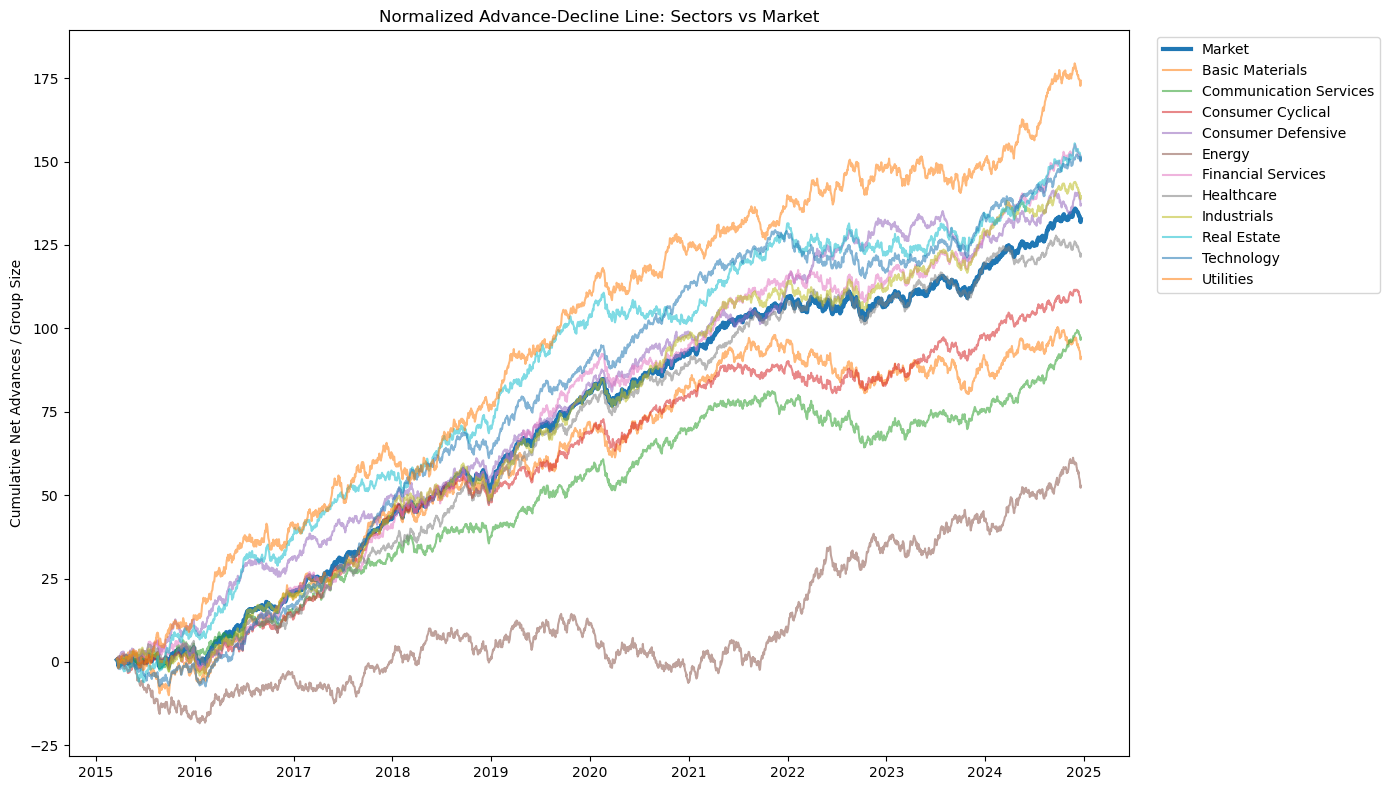

In [58]:
df5_sectors_ratio = df5_sectors_sql.pivot(
    index='date',
    columns='sector',
    values='cum_line_ratio'
)

df5_market_ratio = df5_market_sql.set_index('date').rename(
    columns={'cum_line_ratio_market': 'Market'}
)

df_plot_1 = df5_sectors_ratio.merge(
    df5_market_ratio[['Market']],
    left_index=True,
    right_index=True,
    how='left'
)

ordered_cols = ['Market'] + [col for col in df_plot_1.columns if col != 'Market']

plt.figure(figsize=(14, 8))

for col in ordered_cols:
    if col == 'Market':
        plt.plot(df_plot_1.index, df_plot_1[col], linewidth=3, label=col)
    else:
        plt.plot(df_plot_1.index, df_plot_1[col], alpha=0.55, label=col)

plt.title('Normalized Advance-Decline Line: Sectors vs Market')
plt.ylabel('Cumulative Net Advances / Group Size')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Average Market-Adjusted Return by Sector and Volatility Regime

This heatmap shows the average daily market-adjusted return for each sector across different volatility regimes.

A positive value means that, on average, stocks in the sector outperformed the market during that regime, while a negative value indicates relative underperformance. This helps compare which sectors were more resilient or weaker during periods of elevated market stress.

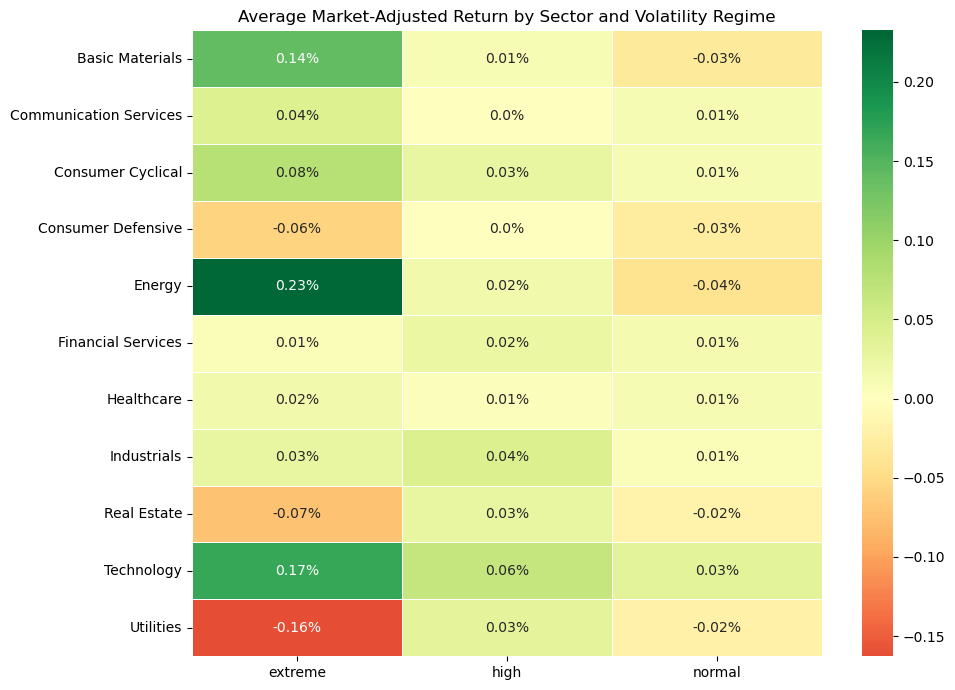

In [56]:
df_plot_2 = (
    df3_ranking[['date', 'symbol', 'sector', 'market_adj_return']]
    .merge(df4_VIX[['date', 'regime']], on='date', how='left')
    .groupby(['sector', 'regime'], as_index=False)['market_adj_return']
    .mean()
    .pivot(index='sector', columns='regime', values='market_adj_return')
)

df_plot_2_pct = df_plot_2 * 100

annot_labels = df_plot_2_pct.round(2).astype(str) + '%'

plt.figure(figsize=(10, 7))

sns.heatmap(
    df_plot_2_pct,
    annot=annot_labels,
    fmt='',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5
)

plt.title('Average Market-Adjusted Return by Sector and Volatility Regime')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Market Breadth with Volatility Regime Shading

This chart shows the normalized cumulative advance-decline line for the overall market, with background shading indicating different volatility regimes.

The line tracks market breadth over time, while the shaded areas help relate changes in breadth to periods of normal, high, or extreme market volatility. This makes it easier to see whether broad market participation tended to strengthen or weaken during more stressful conditions.

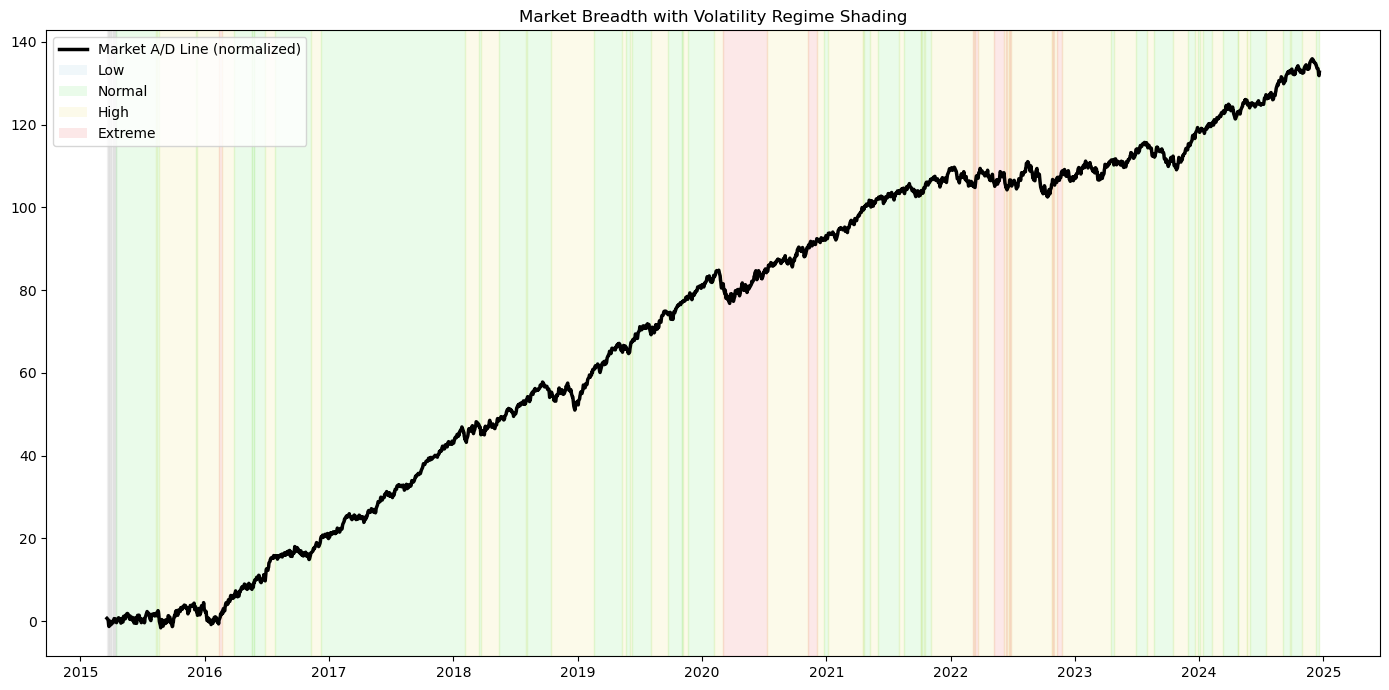

In [66]:
df_ad = df5_market_sql.copy()
df_ad['date'] = pd.to_datetime(df_ad['date'])

df_reg = df4_VIX[['date', 'regime']].copy()
df_reg['date'] = pd.to_datetime(df_reg['date'])
df_reg = df_reg.sort_values('date')

df_plot = (
    df_ad[['date', 'cum_line_ratio_market']]
    .merge(df_reg, on='date', how='left')
    .sort_values('date')
)

regime_colors = {
    'low': 'lightblue',
    'normal': 'lightgreen',
    'high': 'khaki',
    'extreme': 'lightcoral'
}

plt.figure(figsize=(14, 7))

plt.plot(
    df_plot['date'],
    df_plot['cum_line_ratio_market'],
    color='black',
    linewidth=2.5,
    label='Market A/D Line (normalized)'
)

start_idx = 0
for i in range(1, len(df_plot)):
    if df_plot['regime'].iloc[i] != df_plot['regime'].iloc[i - 1]:
        regime = df_plot['regime'].iloc[i - 1]
        plt.axvspan(
            df_plot['date'].iloc[start_idx],
            df_plot['date'].iloc[i],
            color=regime_colors.get(regime, 'lightgray'),
            alpha=0.18
        )
        start_idx = i

last_regime = df_plot['regime'].iloc[-1]
plt.axvspan(
    df_plot['date'].iloc[start_idx],
    df_plot['date'].iloc[-1],
    color=regime_colors.get(last_regime, 'lightgray'),
    alpha=0.18
)

legend_handles = [
    plt.Line2D([0], [0], color='black', lw=2.5, label='Market A/D Line (normalized)'),
    Patch(facecolor=regime_colors['low'], edgecolor='none', alpha=0.18, label='Low'),
    Patch(facecolor=regime_colors['normal'], edgecolor='none', alpha=0.18, label='Normal'),
    Patch(facecolor=regime_colors['high'], edgecolor='none', alpha=0.18, label='High'),
    Patch(facecolor=regime_colors['extreme'], edgecolor='none', alpha=0.18, label='Extreme')
]

plt.legend(handles=legend_handles, loc='upper left')
plt.title('Market Breadth with Volatility Regime Shading')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()